# scikit-learn Delaney Regression Baseline

This notebook is the first regression baseline for the project.

Task: predict measured log solubility using the processed Delaney ESOL dataset
Models: Ridge regression and random forest regressor

Why this dataset first:
- small, clean tabular schema
- no missing target values
- interpretable descriptor columns

In [45]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid")
RANDOM_SEED = 42

In [46]:
PROJECT_ROOT = Path.cwd().parent.resolve()
DATA_DIR = Path(os.environ.get("DATA_DIR"))

delaney = pd.read_csv(DATA_DIR / "delaney-processed.csv")

feature_columns = [
    "ESOL predicted log solubility in mols per litre",
    "Minimum Degree",
    "Molecular Weight",
    "Number of H-Bond Donors",
    "Number of Rings",
    "Number of Rotatable Bonds",
    "Polar Surface Area",
]
target_column = "measured log solubility in mols per litre"

print("Shape:", delaney.shape)
display(delaney.head())

Shape: (1128, 10)


,Compound ID,ESOL predicted log solubility in mols per litre,Minimum Degree,Molecular Weight,Number of H-Bond Donors,Number of Rings,Number of Rotatable Bonds,Polar Surface Area,measured log solubility in mols per litre,smiles
0,Amigdalin,-0.974,1,457.432,7,3,7,202.32,-0.77,OCC3OC(OCC2OC(OC(C#N)c1ccccc1)C(O)C(O)C2O)C(O)C(O)C3O
1,Fenfuram,-2.885,1,201.225,1,2,2,42.24,-3.30,Cc1occc1C(=O)Nc2ccccc2
2,citral,-2.579,1,152.237,0,0,4,17.07,-2.06,CC(C)=CCCC(C)=CC(=O)
3,Picene,-6.618,2,278.354,0,5,0,0.00,-7.87,c1ccc2c(c1)ccc3c2ccc4c5ccccc5ccc43
4,Thiophene,-2.232,2,84.143,0,1,0,0.00,-1.33,c1ccsc1


## Data Checks

,count,mean,std,min,25%,50%,75%,max
ESOL predicted log solubility in mols per litre,1128.0,-2.988192,1.683220,-9.702,-3.94825,-2.870,-1.84375,1.091
Minimum Degree,1128.0,1.058511,0.238560,0.000,1.00000,1.000,1.00000,2.000
Molecular Weight,1128.0,203.937074,102.738077,16.043,121.18300,182.179,270.37200,780.949
Number of H-Bond Donors,1128.0,0.701241,1.089727,0.000,0.00000,0.000,1.00000,11.000
Number of Rings,1128.0,1.390957,1.318286,0.000,0.00000,1.000,2.00000,8.000
Number of Rotatable Bonds,1128.0,2.177305,2.640974,0.000,0.00000,1.000,3.00000,23.000
Polar Surface Area,1128.0,34.872881,35.383593,0.000,0.00000,26.300,55.44000,268.680
measured log solubility in mols per litre,1128.0,-3.050102,2.096441,-11.600,-4.31750,-2.860,-1.60000,1.580


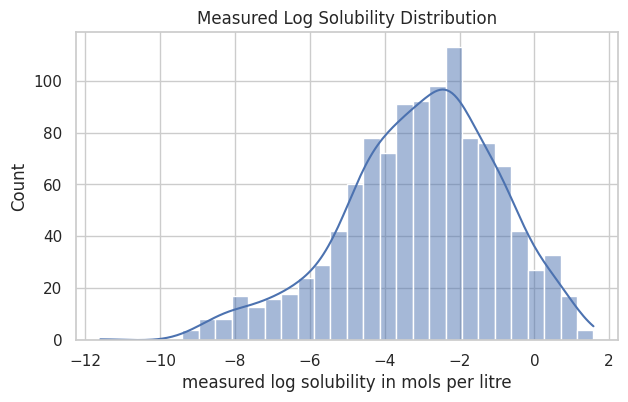

In [47]:
display(delaney[feature_columns + [target_column]].describe().T)

plt.figure(figsize=(7, 4))
sns.histplot(delaney[target_column], bins=30, kde=True)
plt.title("Measured Log Solubility Distribution")
plt.show()

In [48]:
X = delaney[feature_columns]
y = delaney[target_column]

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=RANDOM_SEED
)
X_valid, X_test, y_valid, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=RANDOM_SEED
)

print("Train:", len(X_train), "Valid:", len(X_valid), "Test:", len(X_test))

Train: 789 Valid: 169 Test: 170


## Models

In [49]:
ridge_model = Pipeline(
    [
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=1.0)),
    ]
)

forest_model = RandomForestRegressor(
    n_estimators=300,
    min_samples_leaf=2,
    random_state=RANDOM_SEED,
)

models = {
    "ridge": ridge_model,
    "random_forest": forest_model,
}

results = []
predictions_by_model = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    valid_pred = model.predict(X_valid)
    results.append(
        {
            "model": name,
            "rmse": float(np.sqrt(mean_squared_error(y_valid, valid_pred))),
            "mae": float(mean_absolute_error(y_valid, valid_pred)),
            "r2": float(r2_score(y_valid, valid_pred)),
        }
    )
    predictions_by_model[name] = valid_pred

results_df = pd.DataFrame(results).sort_values("rmse").reset_index(drop=True)
display(results_df.round(4))

,model,rmse,mae,r2
0,random_forest,0.6137,0.4316,0.9252
1,ridge,0.8650,0.6414,0.8515


In [50]:
best_model_name = results_df.loc[0, "model"]
best_model = models[best_model_name]
test_pred = best_model.predict(X_test)

test_metrics = pd.DataFrame(
    [
        {
            "model": best_model_name,
            "rmse": float(np.sqrt(mean_squared_error(y_test, test_pred))),
            "mae": float(mean_absolute_error(y_test, test_pred)),
            "r2": float(r2_score(y_test, test_pred)),
        }
    ]
)
display(test_metrics.round(4))

,model,rmse,mae,r2
0,random_forest,0.6067,0.4514,0.9099


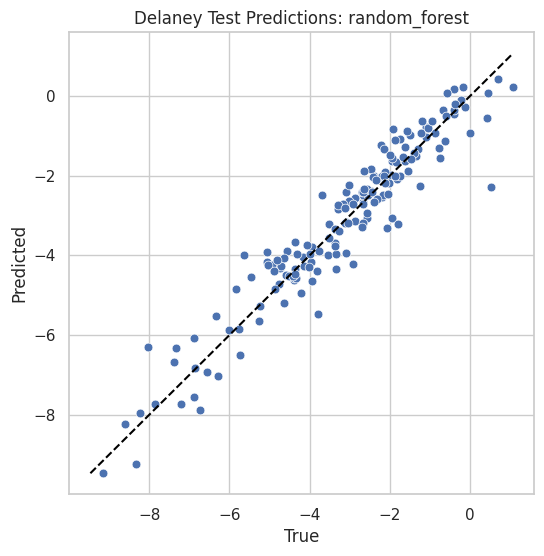

In [51]:
plot_df = pd.DataFrame(
    {
        "true": y_test,
        "predicted": test_pred,
    }
)

plt.figure(figsize=(6, 6))
sns.scatterplot(data=plot_df, x="true", y="predicted", s=40)
line_min = min(plot_df["true"].min(), plot_df["predicted"].min())
line_max = max(plot_df["true"].max(), plot_df["predicted"].max())
plt.plot([line_min, line_max], [line_min, line_max], color="black", linestyle="--")
plt.title(f"Delaney Test Predictions: {best_model_name}")
plt.xlabel("True")
plt.ylabel("Predicted")
plt.show()

## Next Steps

1. add a TensorFlow regressor on the same split
2. compare against PyTorch tabular regression
3. later replace or augment descriptors with RDKit-derived features